### APS1070 Project 3 - Part 1, Git Practice

**Academic Integrity**

This project is individual - it is to be completed on your own. If you have questions, please post your query in the APS1070 Piazza Q&A forums (the answer might be useful to others!).

Do not share your code with others, or post your work online. Do not submit code that you have not written yourself. Students suspected of plagiarism on a project, midterm or exam will be referred to the department for formal discipline for breaches of the Student Code of Conduct.

Please fill out the following:


*   Your **name**: Nijash Sooriyakumaran
*   Your **student number**: 1005104548



## Part 1: Getting started with GitHub [1.5 Marks + 2 Mark Git Submission]


For the first four parts (Part 1-4) of this project, we will work on a [population of countries dataset](https://ourworldindata.org/grapher/population) which reports the population of over 200 countries worldwide from 10000 BCE to 2023. Download the dataset in .csv format using the provided code below. Using the Pandas package, create a population dataframe with only the countries provided in [this GitHub list](https://raw.githubusercontent.com/Sabaae/Dataset/main/countries_list.txt) (237 countries - you should remove all other entities) as rows and years from 1901 to 2023 (123 years) as columns. Then, remove all the countries that have at least missing or invalid value over the years.

In [1]:
import pandas as pd
import requests, io

headers = {"User-Agent": "Mozilla/5.0"}
raw_data = pd.read_csv(
    filepath_or_buffer=io.StringIO(requests.get(
        'https://ourworldindata.org/grapher/population.csv?v=1&csvType=full&useColumnShortNames=true',
        headers=headers).text),
    index_col=False)

countries_list_url = "https://raw.githubusercontent.com/Sabaae/Dataset/main/countries_list.txt"

/Users/nijashsooriya/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:34: NotOpenSSLWarning: urllib3 v2.0 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [13]:
import numpy as np
import requests 

#Countries list
countries = requests.get(countries_list_url, headers= headers).text.splitlines()

countries = [c.strip() for c in countries if c.strip()]
#Identify population while exception handling
value_col = [c for c in raw_data.columns if c not in ("entity", "code", "year")][0]


#Filter from 1901 to 2023
df = raw_data[raw_data["entity"].isin(countries)]
df  = df[(df["year"] >= 1901) & (df["year"] <= 2023)]

#Get countries as rows and years as column
pop = df.pivot(index = 'entity', columns = 'year', values = value_col)

pop = pop.reindex(columns=range(1901, 2024))
#Remove empty values 
pop =  pop.dropna(axis = 0)
pop

year,1901,1902,1903,1904,1905,1906,1907,1908,1909,1910,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
entity,,,,,,,,,,,,,,,,,,,,,
Afghanistan,4751177.0,4802500.0,4861833.0,4921891.0,4982681.0,5044212.0,5106495.0,5169536.0,5300178.0,5504191.0,...,32792528.0,33831767.0,34700613.0,35688941.0,36743040.0,37856125.0,39068977.0,40000410.0,40578847.0,41454762.0
Albania,813539.0,821036.0,828461.0,835954.0,843514.0,851143.0,858841.0,866609.0,874016.0,881057.0,...,2903748.0,2898634.0,2897868.0,2898245.0,2894229.0,2885011.0,2871950.0,2849641.0,2827614.0,2811660.0
Algeria,4787149.0,4859600.0,4939332.0,5020372.0,5102742.0,5186463.0,5271557.0,5358048.0,5433528.0,5497750.0,...,39205035.0,40019528.0,40850719.0,41689302.0,42505033.0,43294551.0,44042094.0,44761099.0,45477391.0,46164222.0
Andorra,4551.0,4581.0,4610.0,4640.0,4670.0,4700.0,4730.0,4761.0,4802.0,4855.0,...,73755.0,72195.0,72197.0,73780.0,75181.0,76492.0,77397.0,78379.0,79722.0,80869.0
Angola,3083888.0,3064493.0,3043335.0,3022320.0,3001447.0,2980714.0,2960121.0,2939666.0,2921666.0,2906100.0,...,27160767.0,28157802.0,29183072.0,30234836.0,31297160.0,32375633.0,33451139.0,34532427.0,35635028.0,36749909.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Venezuela,2733334.0,2765603.0,2796321.0,2827377.0,2858773.0,2890514.0,2922603.0,2955044.0,2985778.0,3014767.0,...,30254080.0,30573968.0,30765719.0,30565331.0,29807591.0,28938096.0,28444080.0,28237830.0,28213015.0,28300861.0
Vietnam,12199511.0,12734169.0,13412346.0,14126641.0,14878976.0,15671378.0,16505981.0,17385031.0,18088666.0,18608564.0,...,91679582.0,92823254.0,94000115.0,95176978.0,96237319.0,97173778.0,98079196.0,98935101.0,99680656.0,100352189.0
Yemen,2984894.0,3006808.0,3033193.0,3059809.0,3086657.0,3113742.0,3141063.0,3168624.0,3196638.0,3225110.0,...,30226311.0,31159378.0,32109023.0,33090923.0,34085181.0,35111416.0,36134867.0,37140234.0,38222878.0,39390800.0


1. Write a function to do the following: **[0.5]**
    * Takes the dataframe, and your list of countries/regions as inputs (Afghanistan, Albania, Algeria, ...)
    * Plots time-series for the input list (it is best to plot each country in a separate graph (subplot), so you can easily compare them.)
    
2. Apply `StandardScalar` to the data. Each year should have a `mean` of zero and a `StD` of 1. **[0.25]**
3. Pick two countries whose names are closest to your first name using string edit distance.
Hint: you can use `Levenshtein.distance()` from the python-Levenshtein package. You may find [this link](https://www.geeksforgeeks.org/python/introduction-to-python-levenshtein-module/) helpful.
4. Run the function in `step 1` on both the original as well as the standardized dataset for the two countries you picked in `step 3` plus `Japan`, `Bosnia and Herzegovina`, `Latvia`, and `United Arab Emirates`. (If you have already selected one of these countries, go down the list and pick the next one you haven't selected) **[0.25]**
5. Discuss the trends in the standardized time-series for all these countries. What does it mean if the curve goes up or down? What does the sign of values indicate? **[0.5]**

Closest two countries: ['Fiji', 'Iran']

 Distance is:  {'Fiji': 4, 'Iran': 4}
Closest two excluding fixed list: ['Fiji', 'Iran']

 Distance is:  {'Fiji': 4, 'Iran': 4}

Selected countries:  ['Fiji', 'Iran', 'Japan', 'Bosnia and Herzegovina', 'Latvia', 'United Arab Emirates']


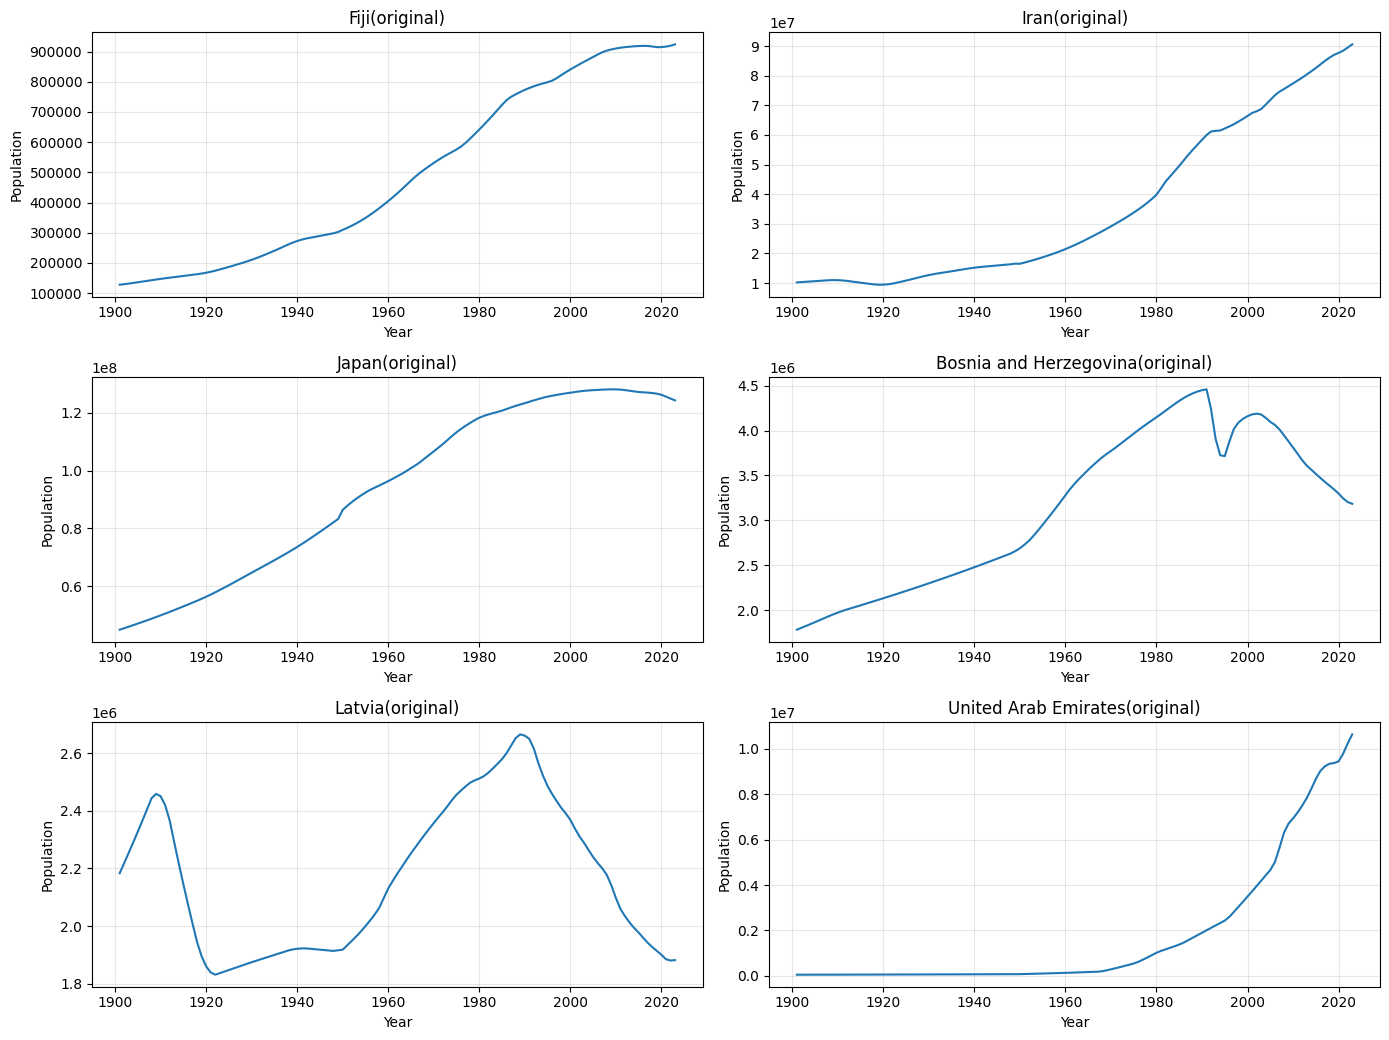

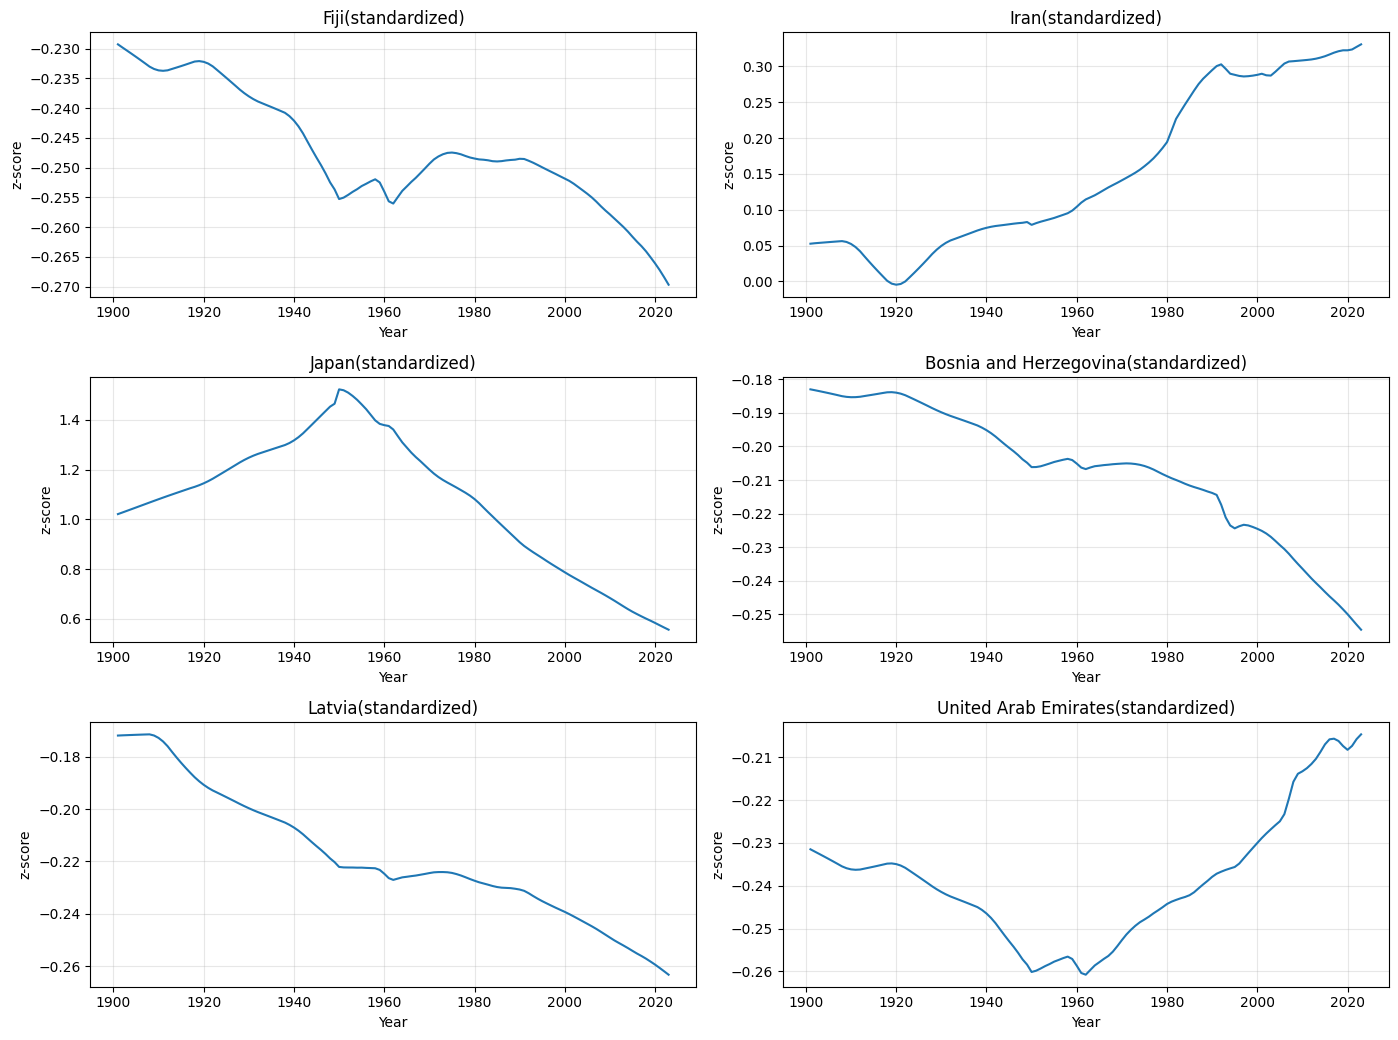

In [18]:
import matplotlib.pyplot as plt
import math
from sklearn.preprocessing import StandardScaler
import Levenshtein 

#Plotting function
def plot_timeseries(data, country_list, title_suffix = '', ylabel = "Population"):
    present = [c for c in country_list if c in data.index]
    missing = [c for c in country_list if c not in data.index]

    if missing:
        print("Not in dataframe:", missing)

    n = len(present)
    ncols = 2
    nrows= math.ceil(n/ncols)
    fig, axes =  plt.subplots(nrows, ncols, figsize = (14, 3.5*nrows))
    axes = np.array(axes).flatten()

    for i, country in enumerate(present):
        ax = axes[i]
        ax.plot(data.columns, data.loc[country])
        ax.set_title(f"{country}{title_suffix}")
        ax.set_xlabel("Year")
        ax.set_ylabel(ylabel)
        ax.grid(alpha = 0.3)
    
    for j in range(n, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()

#2. Standard scaler
scaler = StandardScaler()
pop_scaled = pd.DataFrame(scaler.fit_transform(pop), index = pop.index, columns = pop.columns)


# Task 3, two countries closest to my name
first_name = "Nijash"
#Iterate through all the countries names and standardize to lower case
dists = {c: Levenshtein.distance(first_name.lower(), c.lower()) for c in pop.index}
closest_two = sorted(dists, key = dists.get)[:2]
print("Closest two countries:", closest_two)
print("\n Distance is: ", {c: dists[c] for c in closest_two})

#Task 4
fixed = ["Japan", "Bosnia and Herzegovina", "Latvia", "United Arab Emirates"]

#This is going to sort all the countries closest to my name to ensure that there are no clashes when i take union of fixed and closest_two 
ranked = sorted(pop.index, key = lambda c: dists[c])

#Go through ranking skipping any that are in fixed list
closest_two = []
for c in ranked:
    if c not in fixed:
        closest_two.append(c)
    if len(closest_two) == 2:
        break

print("Closest two excluding fixed list:", closest_two)
print("\n Distance is: " , {c: dists[c] for c in closest_two})

selected = closest_two + fixed 
print("\nSelected countries: ", selected )

plot_timeseries(pop, selected, title_suffix= "(original)")
plot_timeseries(pop_scaled, selected, title_suffix= "(standardized)", ylabel = "z-score")

### Task 5 

Each year was standardized independently, so every value is a cross-sectional z-score; how far a country's population sits from the average countries population in that same year, measured in standard deviations. The standardized curves therefore describe each country's standing relative to all other countries over time, rather than its own absolute growth. Reminder for the z-score formula:

$$z = \frac{(x - \mu)}{\sigma}$$

The meaning of the sign: a positive value indiicates the country was more populus than the average country that year; a negative value implies it was below average. ONly Iran and Japan are positive within these countries displayed. Fiji, Bosnia, Latvia, and UAE stay negative across all 123 years. This is because the populatoin distribution across countries is heavily right skewed: a few very large countries pull the yearly mean up and inflate the standard deviation. 

The slope denotes the rate of change of that countries populations with respect to the average country's population. Japan is positive but its z-score peaks around 1950 and declines to 0.55 by 2023, while its raw population kept rising until 2010. The reconciliation is that Japan grew slower than the average country's growth, so its relative lead shrank. UAE is the opposite: still below average but its z-score is U-shaped, bottoming near 1960 and then climbing steeply, reflecting rapid population growth closing the gap with the average country. Iran is both above average and rising (especially after 1960), indiciating a relative gain, the small dip twoards zero around 1920 reflects population setback before growth. Fiji, Latvia, and Bosnia stay below average and drift slowly downward, meaning their relative standing erodes as larger countries outgrow them. 